## Implement K-Means Clustering using Synthetic Data from Blobs

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set() #Plot styling
import numpy as np

In [5]:
df = pd.read_csv("loan_data.csv")
print(df.head())
print(df.info())

   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0        0   

In [15]:
# Keep numeric
df_num = df.select_dtypes(include=[np.number])

# Fill missing
df_num = df_num.fillna(df_num.mean())

REMOVE BAD FEATURES (binary / low variance)

In [16]:
# Remove columns with very low unique values (like 0/1)
good_cols = []

for col in df_num.columns:
    if df_num[col].nunique() > 10:   # keeps continuous features
        good_cols.append(col)

df_good = df_num[good_cols]

print("Selected columns:", df_good.columns)

Selected columns: Index(['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
       'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths',
       'delinq.2yrs'],
      dtype='object')


Use ONLY 2 BEST columns for visualization

In [18]:
# Take first 2 good columns
X_vis = df_good.iloc[:, :2].values

print("Using features:", df_good.columns[:2])

Using features: Index(['int.rate', 'installment'], dtype='object')


**Visualize Raw Data (like blobs)**

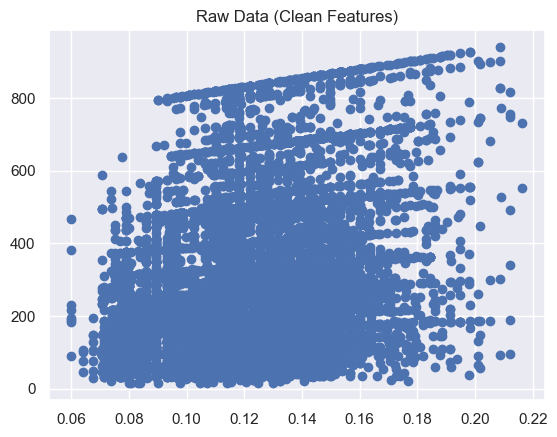

In [19]:
plt.scatter(X_vis[:,0], X_vis[:,1])
plt.title("Raw Data (Clean Features)")
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

## apply k-means

In [23]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_scaled)   # SAME X_scaled (2 features)

y_kmeans = kmeans.predict(X_scaled)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

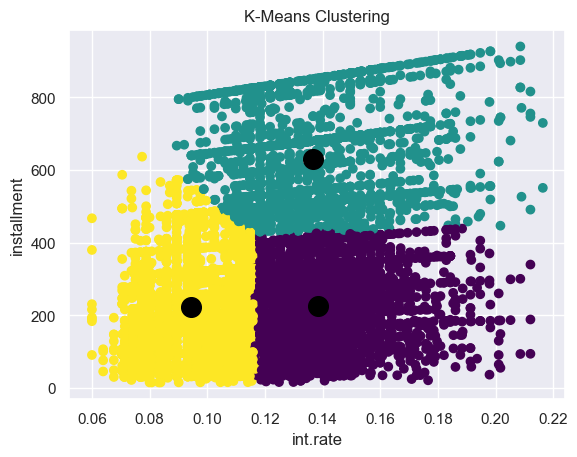

In [25]:
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_kmeans, cmap='viridis')

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centers[:,0], centers[:,1], c='black', s=200)

plt.xlabel(df_good.columns[0])
plt.ylabel(df_good.columns[1])
plt.title("K-Means Clustering")
plt.show()

## PCA

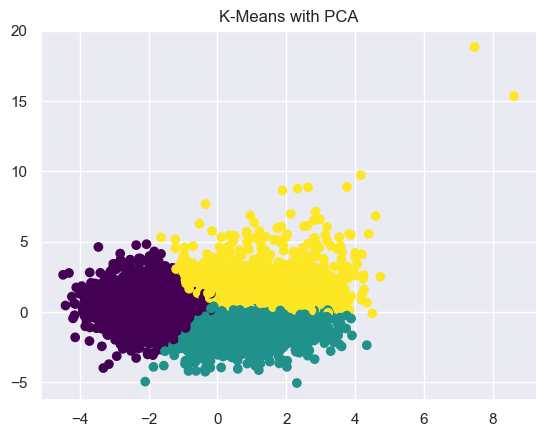

In [29]:
from sklearn.decomposition import PCA

X_scaled_full = StandardScaler().fit_transform(df_good)

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled_full)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("K-Means with PCA")
plt.show()

 Different Number of Clusters

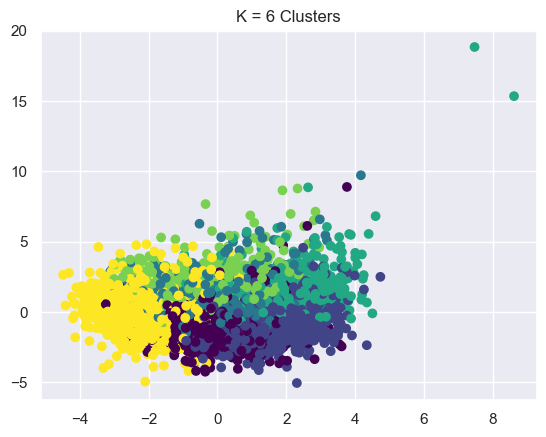

In [30]:
labels = KMeans(6, random_state=0, n_init=10).fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("K = 6 Clusters")
plt.show()

LIMITATION OF K-MEANS (REAL DATA VERSION)

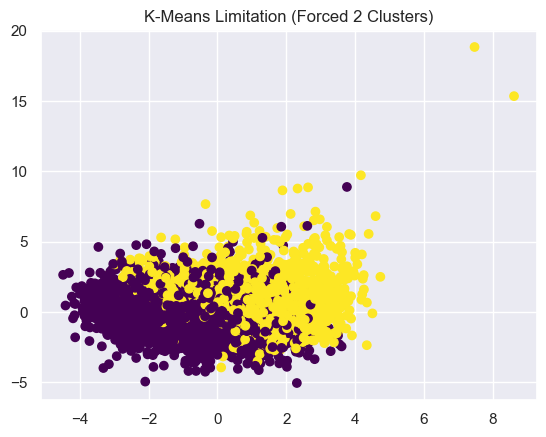

In [31]:
labels = KMeans(2, random_state=0).fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("K-Means Limitation (Forced 2 Clusters)")
plt.show()